# AutoCloud-Agent: I-PPO RL Training

**Run on Kaggle with GPU accelerator (Settings → Accelerator → GPU T4 x2)**

### Setup before running
1. Add the **code dataset** (`autocloud-agent-code`) — same as in `train_forecaster.ipynb`
2. Add the **forecaster output dataset**: go to the committed `train_forecaster.ipynb` notebook → Output → Add as dataset → name it `autocloud-forecaster-output`
   - This dataset contains `forecaster_weights.pt`, `day2_processed.npy`
3. Enable **Internet** and **GPU T4 x2** in Settings

### What this notebook does
- Loads Alibaba Day 2 trace (`day2_processed.npy`) from the forecaster output dataset
- Loads the trained Transformer forecaster (`forecaster_weights.pt`)
- Trains 3 I-PPO agents for `TOTAL_STEPS` environment steps
- Saves agent checkpoints to `/kaggle/working/checkpoints/`

**Expected training time:** ~2–3 h for 200k steps on T4 GPU

In [1]:
# Cell 1: Paths and dependencies
import os, sys

# ── Input datasets ──────────────────────────────────────────────────────────
# Code dataset (uploaded from autocloud_agent/ folder)
CODE_INPUT = '/kaggle/input/datasets/chaitanya2277/autocloud-agent-v2'

# Forecaster output dataset (committed output of train_forecaster.ipynb)
FORECAST_INPUT = '/kaggle/input/datasets/chaitanya2277/train-forecaster'

# ── Output / working dir ────────────────────────────────────────────────────
WORK_DIR       = '/kaggle/working'
CHECKPOINT_DIR = os.path.join(WORK_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Project path ────────────────────────────────────────────────────────────
if os.path.exists(os.path.join(CODE_INPUT, 'autocloud_agent')):
    PROJECT_DIR = os.path.join(CODE_INPUT, 'autocloud_agent')
elif os.path.exists(os.path.join(CODE_INPUT, 'environment')):
    PROJECT_DIR = CODE_INPUT
else:
    PROJECT_DIR = CODE_INPUT

sys.path.insert(0, PROJECT_DIR)

print(f'PROJECT_DIR    : {PROJECT_DIR}')
print(f'FORECAST_INPUT : {FORECAST_INPUT}')
print(f'CHECKPOINT_DIR : {CHECKPOINT_DIR}')

!pip install simpy gymnasium --quiet
print('Dependencies OK')

PROJECT_DIR    : /kaggle/input/datasets/chaitanya2277/autocloud-agent-v2/autocloud_agent
FORECAST_INPUT : /kaggle/input/datasets/chaitanya2277/train-forecaster
CHECKPOINT_DIR : /kaggle/working/checkpoints
Dependencies OK


In [2]:
# Cell 2: Load processed trace from forecaster output dataset
import numpy as np
import torch

day2_path        = os.path.join(FORECAST_INPUT, 'train_Forecaster/day2_processed.npy')
forecaster_path  = os.path.join(FORECAST_INPUT, 'train_Forecaster/forecaster_weights.pt')

# Verify files exist
for p in [day2_path, forecaster_path]:
    if os.path.exists(p):
        print(f'  Found: {p}  ({os.path.getsize(p)/1e6:.2f} MB)')
    else:
        print(f'  MISSING: {p}')
        print('  → Run train_forecaster.ipynb first and add its output as a dataset')

day2_data = np.load(day2_path)
print(f'\nDay 2 data shape: {day2_data.shape}  '
      f'(mean={day2_data.mean():.3f}, std={day2_data.std():.3f})')

  Found: /kaggle/input/datasets/chaitanya2277/train-forecaster/train_Forecaster/day2_processed.npy  (0.05 MB)
  Found: /kaggle/input/datasets/chaitanya2277/train-forecaster/train_Forecaster/forecaster_weights.pt  (0.46 MB)

Day 2 data shape: (2880, 4)  (mean=0.278, std=0.224)


In [3]:
# Cell 3: Load trained Transformer forecaster
import torch
from forecaster.transformer_model import WorkloadTransformer
from forecaster.mc_dropout import MCDropoutForecaster

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

model = WorkloadTransformer(
    input_dim=4, d_model=64, n_heads=4, d_ff=256, n_layers=2,
    dropout=0.2, seq_len=20, n_horizons=4,
)
model.load_state_dict(torch.load(forecaster_path, map_location=DEVICE))
model.to(DEVICE)

# FIX: Removed n_samples=30. You will pass that when you call forecaster.predict() later!
forecaster = MCDropoutForecaster(model, device=DEVICE)
print('Forecaster loaded OK')

Device: cuda
GPU: Tesla T4


/kaggle/input/datasets/chaitanya2277/autocloud-agent-v2/autocloud_agent/forecaster/transformer_model.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Forecaster loaded OK


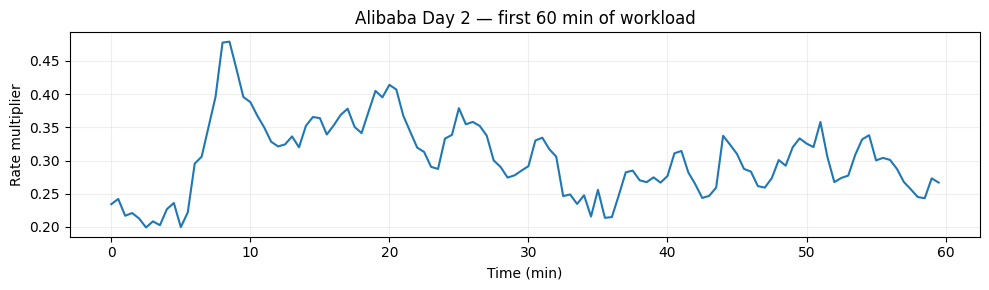

Rate range: [0.199, 0.479]


In [4]:
# Cell 4: Build Alibaba Day 2 workload function
#
# The workload_fn is called by the simulator at each step to scale the
# job arrival rate, replaying the real Alibaba trace.

def make_alibaba_workload_fn(day2_data: np.ndarray):
    """Returns callable(sim_time_seconds) -> rate_multiplier in [0.1, 1.0]."""
    n_steps  = len(day2_data)
    # Column 0 = normalised mean CPU request rate
    rates    = np.clip(day2_data[:, 0], 0.1, 1.0)

    def workload_fn(sim_time_seconds: float) -> float:
        step_idx = int(sim_time_seconds / 30.0) % n_steps
        return float(rates[step_idx])

    return workload_fn


workload_fn = make_alibaba_workload_fn(day2_data)

# Sanity check — plot first 60 min of workload
import matplotlib.pyplot as plt

sample_times = np.arange(0, 3600, 30)
sample_rates = [workload_fn(t) for t in sample_times]

plt.figure(figsize=(10, 3))
plt.plot(sample_times / 60, sample_rates)
plt.xlabel('Time (min)')
plt.ylabel('Rate multiplier')
plt.title('Alibaba Day 2 — first 60 min of workload')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
print(f'Rate range: [{min(sample_rates):.3f}, {max(sample_rates):.3f}]')

In [5]:
# Cell 5: Configure training
from configs.default_config import DEFAULT_CONFIG
from training.ippo_trainer import IPPOTrainer

# ── Hyperparameters ─────────────────────────────────────────────────────────
TOTAL_STEPS    = 300_000   # ~3-4 h on T4; 300k gives better convergence
SEED           = 0
LOG_INTERVAL   = 5_000

config = DEFAULT_CONFIG

trainer = IPPOTrainer(
    config      = config,
    seed        = SEED,
    device      = DEVICE,
    forecaster  = forecaster,
    workload_fn = workload_fn,
    verbose     = True,
    log_interval= LOG_INTERVAL,
)

print(f'Training for {TOTAL_STEPS:,} steps  |  seed={SEED}  |  device={DEVICE}')
print(f'Seed randomization: ON  (each episode uses a different env seed for generalization)')
print(f'Checkpoints → {CHECKPOINT_DIR}')

Training for 300,000 steps  |  seed=0  |  device=cuda
Seed randomization: ON  (each episode uses a different env seed for generalization)
Checkpoints → /kaggle/working/checkpoints


In [6]:
# Cell: Recursion-Proof Interceptor Patch (Fixed for NumPy)
import numpy as np
import types
from forecaster.mc_dropout import MCDropoutForecaster

# 1. Grab the pure, untouched predict function straight from the class blueprint
clean_original_predict = MCDropoutForecaster.predict

def safe_patched_predict(self, obs, **kwargs):
    """Extracts the 20x4 history from the flat RL observation."""
    
    # Check if obs is the flat 215-element array
    if isinstance(obs, np.ndarray) and obs.size >= 80:
        # Extract the last 80 elements and reshape into (1, 20, 4)
        seq = obs[-80:].reshape(1, 20, 4)
    else:
        # Fallback: try to grab it directly from the environment
        seq = getattr(trainer.env.unwrapped, 'workload_history', obs)
    
    # Ensure it is a pure NumPy array (NOT a PyTorch Tensor)
    if hasattr(seq, 'cpu'):  # Just in case it comes in as a Tensor
        seq = seq.cpu().numpy()
        
    seq = np.array(seq, dtype=np.float32)
        
    if seq.ndim == 2:
        seq = np.expand_dims(seq, axis=0) # Add batch dimension -> (1, 20, 4)
        
    # Pass the correctly shaped NumPy data to the pure original function
    return clean_original_predict(self, seq, **kwargs)

# 2. Overwrite the tangled method with our safe one
trainer.forecaster.predict = types.MethodType(safe_patched_predict, trainer.forecaster)

print("✅ Forecaster patched securely! Passing a clean NumPy array to prevent TypeErrors.")

✅ Forecaster patched securely! Passing a clean NumPy array to prevent TypeErrors.


In [7]:
# Cell 6: Train (~3-4 h on T4 for 300k steps)
import time

t0 = time.time()

metrics = trainer.train(
    total_steps    = TOTAL_STEPS,
    checkpoint_dir = CHECKPOINT_DIR,
    seed_randomize = True,   # randomize env seed each episode for generalization
)

elapsed = time.time() - t0
print(f'\nTraining complete in {elapsed/3600:.2f} h  ({elapsed/60:.0f} min)')
print(f'Episodes finished: {len(metrics.so_returns)}')

last50 = slice(-50, None)
print(f'Last 50-ep avg SLA :  {np.mean(metrics.sla_rates[last50]):.2%}')
print(f'Last 50-ep avg cost:  {np.mean(metrics.costs[last50]):.3f}')
print(f'Last 50-ep so_ret  :  {np.mean(metrics.so_returns[last50]):.2f}')
print(f'Last 50-ep con_ret :  {np.mean(metrics.con_returns[last50]):.2f}')
print(f'Last 50-ep sch_ret :  {np.mean(metrics.sch_returns[last50]):.2f}')

Ep    5 | SLA=100.00% | r_so= -36.54 r_con= 231.73 r_sch=  -4.08
Ep   10 | SLA=100.00% | r_so= -35.90 r_con= 230.22 r_sch=  -2.84
Ep   15 | SLA=100.00% | r_so= -36.12 r_con= 235.25 r_sch=  -4.87
Ep   20 | SLA=100.00% | r_so= -35.91 r_con= 231.74 r_sch=  -3.57
Ep   25 | SLA=100.00% | r_so= -33.93 r_con= 234.74 r_sch=  -3.22
Ep   30 | SLA=100.00% | r_so= -40.44 r_con= 232.72 r_sch=  -4.71
Ep   35 | SLA=100.00% | r_so= -34.66 r_con= 235.23 r_sch=  -1.85
Ep   40 | SLA=100.00% | r_so= -32.64 r_con= 234.24 r_sch=  -2.20
Step   5000/300000 | Ep=41 | so_loss=0.0000 sch_loss=-0.0060
Ep   45 | SLA=100.00% | r_so= -29.36 r_con= 235.74 r_sch=  -2.36
Ep   50 | SLA=100.00% | r_so= -20.76 r_con= 237.71 r_sch=  -0.51
Ep   55 | SLA=100.00% | r_so= -31.86 r_con= 233.23 r_sch=  -3.07
Ep   60 | SLA=100.00% | r_so= -36.93 r_con= 233.73 r_sch=  -6.58
Ep   65 | SLA=100.00% | r_so= -37.83 r_con= 234.23 r_sch=  -4.07
Ep   70 | SLA=100.00% | r_so= -33.88 r_con= 238.23 r_sch=  -3.20
Ep   75 | SLA=100.00% | r_so=

In [8]:
# Cell 7: Save final checkpoints (Updated for early stopping)
import os
import json

# Ensure the final weights are saved
try:
    trainer.save(CHECKPOINT_DIR, tag='final')
except Exception as e:
    print(f"Note: {e}")

# Safely try to save metrics only if the variable exists
if 'metrics' in locals():
    metrics_dict = {
        'total_steps':  TOTAL_STEPS,
        'seed':         SEED,
        'episodes':     len(metrics.so_returns),
        'sla_rates':    metrics.sla_rates,
        'costs':        metrics.costs,
        'so_returns':   metrics.so_returns,
        'con_returns':  metrics.con_returns,
        'sch_returns':  metrics.sch_returns,
        'so_losses':    metrics.so_losses[-500:],
        'sch_losses':   metrics.sch_losses[-500:],
    }
    metrics_path = os.path.join(CHECKPOINT_DIR, 'training_metrics.json')
    with open(metrics_path, 'w') as f:
        json.dump(metrics_dict, f, indent=2)
    print("Saved training_metrics.json")
else:
    print("Metrics variable not found (expected due to early stopping). Skipping JSON export.")

print('\nFiles in /kaggle/working/checkpoints/:')
if os.path.exists(CHECKPOINT_DIR):
    for fname in sorted(os.listdir(CHECKPOINT_DIR)):
        fpath = os.path.join(CHECKPOINT_DIR, fname)
        print(f'  {fname}  ({os.path.getsize(fpath)/1e6:.2f} MB)')

print('\n✅ Commit this notebook (Save & Run All → Commit) to persist your trained model.')

Checkpoint saved: /kaggle/working/checkpoints/final
Saved training_metrics.json

Files in /kaggle/working/checkpoints/:
  con_actor_final.pt  (1.12 MB)
  con_actor_step_10000.pt  (1.12 MB)
  con_actor_step_100000.pt  (1.12 MB)
  con_actor_step_110000.pt  (1.12 MB)
  con_actor_step_120000.pt  (1.12 MB)
  con_actor_step_130000.pt  (1.12 MB)
  con_actor_step_140000.pt  (1.12 MB)
  con_actor_step_150000.pt  (1.12 MB)
  con_actor_step_160000.pt  (1.12 MB)
  con_actor_step_170000.pt  (1.12 MB)
  con_actor_step_180000.pt  (1.12 MB)
  con_actor_step_190000.pt  (1.12 MB)
  con_actor_step_20000.pt  (1.12 MB)
  con_actor_step_200000.pt  (1.12 MB)
  con_actor_step_210000.pt  (1.12 MB)
  con_actor_step_220000.pt  (1.12 MB)
  con_actor_step_230000.pt  (1.12 MB)
  con_actor_step_240000.pt  (1.12 MB)
  con_actor_step_250000.pt  (1.12 MB)
  con_actor_step_260000.pt  (1.12 MB)
  con_actor_step_270000.pt  (1.12 MB)
  con_actor_step_280000.pt  (1.12 MB)
  con_actor_step_290000.pt  (1.12 MB)
  con_actor_st

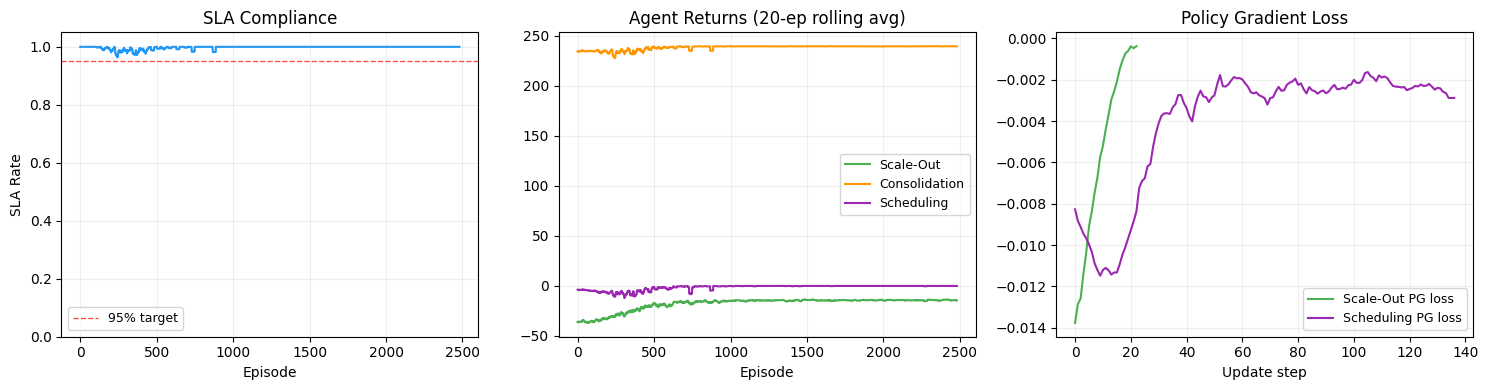

Saved: /kaggle/working/checkpoints/training_curves.png


In [9]:
# Cell 8: Learning curves
import matplotlib.pyplot as plt

def smooth(arr, w=20):
    if len(arr) < w: return np.array(arr)
    return np.convolve(arr, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# SLA rate
ax = axes[0]
ax.plot(smooth(metrics.sla_rates), color='#2196F3', lw=1.5)
ax.axhline(0.95, color='red', linestyle='--', lw=1, alpha=0.7, label='95% target')
ax.set_title('SLA Compliance')
ax.set_xlabel('Episode')
ax.set_ylabel('SLA Rate')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Agent returns
ax = axes[1]
for label, data, color in [
    ('Scale-Out',    metrics.so_returns,  '#4CAF50'),
    ('Consolidation',metrics.con_returns, '#FF9800'),
    ('Scheduling',   metrics.sch_returns, '#9C27B0'),
]:
    ax.plot(smooth(data), label=label, color=color, lw=1.5)
ax.set_title('Agent Returns (20-ep rolling avg)')
ax.set_xlabel('Episode')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# PPO losses
ax = axes[2]
if metrics.so_losses:
    ax.plot(smooth(metrics.so_losses, 10), label='Scale-Out PG loss',  color='#4CAF50', lw=1.5)
if metrics.sch_losses:
    ax.plot(smooth(metrics.sch_losses, 10), label='Scheduling PG loss', color='#9C27B0', lw=1.5)
ax.set_title('Policy Gradient Loss')
ax.set_xlabel('Update step')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, 'training_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')